In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
sentences = ["Đoạn clip ghi lại một lễ hội đèn lồng.",
             "Trên phố, nhiều người mặc hanbok diễu hành, mang theo đủ loại đèn lồng rực rỡ.",
             "Nổi bật ở giữa là một phụ nữ cầm hai đèn lồng tròn lớn màu cam, xung quanh có đèn lồng hình cá, tôm và nhiều kiểu dáng khác.",
             "Tiếp đó, xuất hiện một chiếc đèn lồng khổng lồ hình người trong trang phục truyền thống Hàn Quốc: áo tím viền vàng, váy xanh, hai tay nâng một đèn lồng nhỏ màu cam – xanh phát sáng rực rỡ.",
             "Đoạn clip về một gian trưng bày văn hóa – du lịch.",
             "Ở giữa là bản đồ Việt Nam được kết bằng trái cây màu vàng và nâu.",
             "Phía trước có hai người giới thiệu: một cô gái mặc trang phục dân tộc truyền thống màu nâu, thắt dải yếm xanh – hồng – tím",
             "Một người đàn ông mặc áo thun xanh đậm và quần sáng.",
             "Hảy cho biết đây là khu du lịch quốc gia tại địa điểm nào của Việt Nam (thông tin có ngay dưới bản đồ, được ghi bằng chữ màu xanh lá cây)"]

In [ ]:
vocab = sorted({w for s in sentences for w in s.lower().split()})

vocab_to_idx = {word: idx for idx, word in enumerate(vocab)}
def to_vector(sentence):
  v = np.zeros(len(vocab))
  for w in sentence.lower().split():
    if w in vocab_to_idx:
      v[vocab_to_idx[w]] += 1
  return v
X = np.array([to_vector(s) for s in sentences])
print(X.shape)

(8, 113)


1. Ma trận X là ma trận mỗi câu được ánh xạ thành các số 0 hoặc 1 đại diện cho việc câu đó có các từ nào thuộc từ điển được trích xuất ra từ database là array sentences.
-> Ở đây, ta in X.shape ra (8, 113). Có nghĩa là có tổng cộng 8 câu và 113 từ được trích xuất ra từ 8 câu đó.

In [ ]:
def cosin_similarity(X, Y = None):
  if Y is None:
    Y = X
  X = X / np.linalg.norm(X, axis = 1, keepdims = True)
  Y = Y / np.linalg.norm(Y, axis = 1, keepdims = True)
  return X @ Y.T

In [ ]:
def search(query, top_k = 3):
  Q = np.array([to_vector(query)])
  scores = cosin_similarity(X, Q)
  scores = scores.flatten()
  top_idx = np.argsort(scores)[::-1][:top_k]
  print(f"Top {top_k} câu liên quan tới query: ")
  for i in top_idx:
    if(scores[i] > 0):
       print(f"- {sentences[i]}")

search("tôi thích ăn hanbok và trà sữa đường nâu")

Top 3 câu liên quan tới query: 
- Một người đàn ông mặc áo thun xanh đậm và quần sáng.
- Ở giữa là bản đồ Việt Nam được kết bằng trái cây màu vàng và nâu.
- Trên phố, nhiều người mặc hanbok diễu hành, mang theo đủ loại đèn lồng rực rỡ.


5. Ở đây, kết quả trả ra cho câu truy vấn "tôi thích ăn hanbok và trà sữa đường nâu" lại là câu "Một người đàn ông mặc áo thun xanh đậm và quần sáng."
-> Ta thấy, kết quả có vẻ chưa đúng lắm vì có câu cũng mang chủ đề liên quan tới hàn quốc là "Trên phố, nhiều người mặc hanbok diễu hành, mang theo đủ loại đèn lồng rực rỡ." liên quan hơn. Điều rút ra ở đây đó là, phương pháp BoW đánh giá mức độ quan trọng của các từ là bằng nhau (ví dụ cụ thể ở đây là giữa từ "và" với "hanbok"). Từ đó, kết quả trả về sẽ không đúng với tìm kiếm thực tế.

[[-1.18351781  0.18280861]
 [-0.61446146 -0.28467734]
 [ 0.35322553 -4.09520789]
 [ 5.05358883 -0.06759046]
 [-1.43884706  0.97509651]
 [-2.08470952 -0.58425272]
 [ 0.93170546  3.05547617]
 [-1.01698398  0.81834714]]


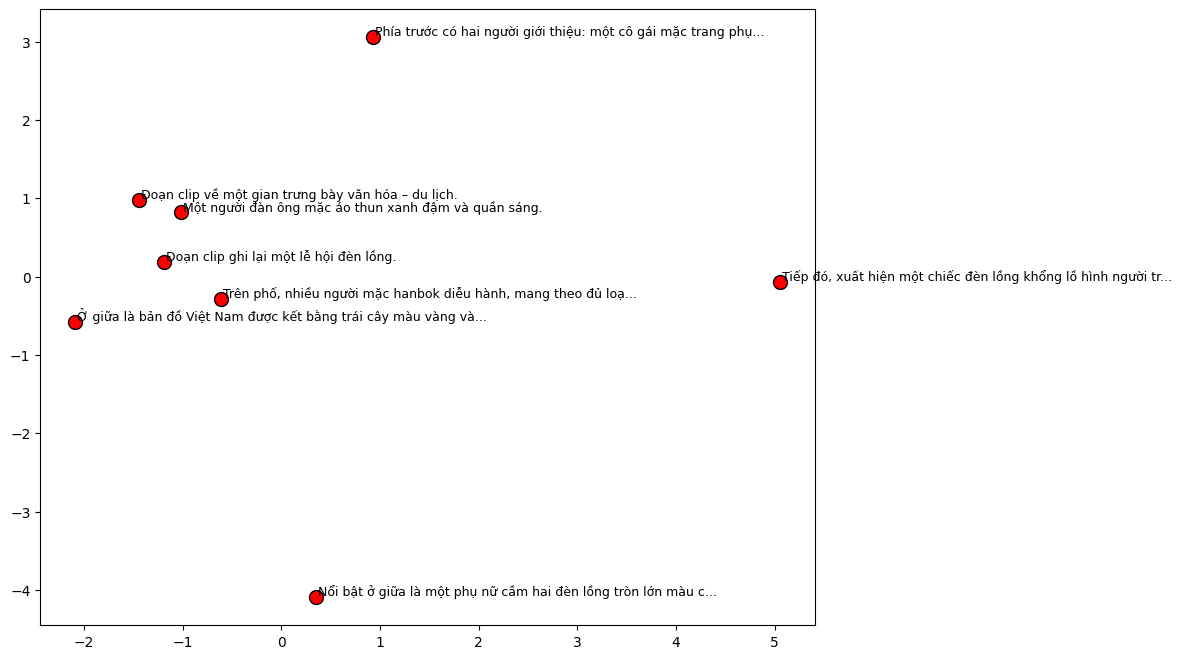

In [ ]:
Xc = X - X.mean(axis = 0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:, :2] * S[:2]
print(coords)

plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], color='red', edgecolors='k', s=100)
for i, sentence in enumerate(sentences):
  short_text = sentence[:60] + "..." if len(sentence) > 60 else sentence
  plt.text(coords[i, 0] + 0.02, coords[i, 1] + 0.02, short_text, fontsize=9)
plt.show()

Các câu cùng chủ đề đã không nằm gần nhau, có thể là vì ngôn ngữ Tiếng Việt nên thuật toán chưa hoạt động hiệu quả (?).
Thuật toán SVD trên là thuật toán PCA bằng việc phân tích vector riêng của dữ liệu. Ta chọn tọa độ (x,y) của dữ liệu là 2 trường vector đầu tiên. Từ đó, ta có thể biểu diễn "ngữ nghĩa" của các câu lên mặt phẳng 2D.